<a href="https://colab.research.google.com/github/Juanma-dev-tech/aprendizaje-automatico-1/blob/main/Trabajo_Pr%C3%A1ctico_1_Procesamiento_de_archivos_PDF_y_an%C3%A1lisis_de_texto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Adquisición y metadatos

Se analizaron los metadatos del documento como parte del proceso de exploración inicia. Se utiliza la librería PyMuPDF (fitz), recomendada por la materia

Paso 1: Instalar la librería

In [ ]:
!pip install pymupdf

Paso 2: Importar librerías

In [ ]:
import requests
import fitz

Paso 3: Descargar pdf (URL)

Durante la descarga del archivo se presentó un inconveniente con la validación del certificado SSL del sitio. Para resolverlo, se desactivó la verificación del certificado en la solicitud HTTP.

In [ ]:
# Paso 3: definir la URL del PDF a descargar
url = "https://biblioteca.camarco.org.ar/wp-content/uploads/08.-Desarrollo-Urbano-Ambientaldig.pdf"

# Se detectó un inconveniente con la validación del certificado SSL del sitio.
# Para permitir la descarga del archivo en el entorno de ejecución (Google Colab),
# se desactiva la verificación del certificado mediante el parámetro verify=False.
response = requests.get(url, verify=False)

# Verificamos que la descarga se haya realizado correctamente
response.raise_for_status()

# Abrimos/creamos el archivo en modo binario ("wb") para guardar correctamente el PDF.
# Esto no afecta el procesamiento posterior del texto, ya que solo se utiliza para almacenar el archivo descargado.
with open("desarrollo_urbano.pdf", "wb") as f:
    f.write(response.content)

print("PDF descargado correctamente")

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'biblioteca.camarco.org.ar'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


PDF descargado correctamente


Significado del warning "Estás descargando un archivo sin verificar el certificado SSL"

Paso 4: Abrir el PDF y analizar los metadatos

In [ ]:
# Se utiliza la librería PyMuPDF para abrir el documento
doc = fitz.open("desarrollo_urbano.pdf")

# Se accede a los metadatos del documento
# Los metadatos contienen información general como autor, título, fecha, etc.
doc.metadata

{'format': 'PDF 1.6',
 'title': 'Sin título-1',
 'author': '',
 'subject': '',
 'keywords': '',
 'creator': 'Adobe InDesign 15.1 (Windows)',
 'producer': 'Adobe PDF Library 15.0',
 'creationDate': "D:20200629141527-03'00'",
 'modDate': "D:20200629141527-03'00'",
 'trapped': '',
 'encryption': None}

Análisis de metadatos:
Se realizó un análisis de los metadatos del documento PDF utilizando la librería PyMuPDF. Se observó que el archivo corresponde a un documento en formato PDF 1.6, generado mediante Adobe InDesign y procesado con Adobe PDF Library.

En cuanto a la información descriptiva, el documento presenta campos incompletos o vacíos, tales como el autor, el asunto y las palabras clave. Asimismo, el título registrado ("Sin título-1") no resulta representativo del contenido.

Este tipo de características es frecuente en documentos diseñados para lectura humana, donde los metadatos no son una prioridad. Como consecuencia, se anticipa la posible presencia de estructuras complejas en el texto, tales como saltos de línea irregulares o elementos de maquetación, lo cual representa un desafío adicional para su procesamiento mediante técnicas de NLP.

## 2. Análisis estructural del texto

Paso 5: Extraer texto

In [ ]:
# La función get_text() de PyMuPDF permite extraer el texto de cada página
# de forma bastante cruda, conservando saltos de línea y parte de la estructura visual del PDF.

for i in range(5):
    texto = doc[i].get_text()
    print(f"\n{'='*60}")
    print(f"PÁGINA {i+1}")
    print(f"{'='*60}\n")
    print(repr(texto))


PÁGINA 1

''

PÁGINA 2

'PLAN DE OBRAS PARA EL\nDESARROLLO URBANO AMBIENTAL\nArq. Juan Carlos Angelomé\ncon la colaboración de: \nArq. Griselda Cicchelli y Lic. Nicolás Angelomé\n'

PÁGINA 3

''

PÁGINA 4

'122\nCONTENIDOS\n01\nINTRODUCCIÓN\n153\n05\nOBJETIVO Y\nMETODOLOGÍA\n155\n107\nLISTADO DE\nPROGRAMAS, PLANES\nY PROYECTOS\nSELECCIONADOS\n159\n3 11\nSELECCIÓN DE\nLA MUESTRA DEL\nESTUDIO\n155\n209\nCARACTERIZACIÓN\nDE LAS INVERSIONES\n166\n415\nPLAN DE OBRAS\n167\n519\nFICHAS DE\nOBRAS DE DUA\n169\n621\nPLAN DE INVERSIÓN\nPARA EL DESARROLLO\nURBANO AMBIENTAL\n169\n789\n'

PÁGINA 5

''


Se realizó la extracción del texto de las primeras cinco páginas del documento utilizando la función get_text() de la librería PyMuPDF. Durante este proceso, se observó que no todas las páginas contienen texto, ya que algunas corresponden a portadas o imágenes, por lo que no es posible extraer contenido de ellas.

En las páginas que sí presentan texto, se nota que el contenido no está en un formato continuo, sino que aparece dividido en varias líneas, muchas veces con palabras en mayúsculas y números mezclados con el texto.

En cuanto a la estructura, los párrafos no están claramente definidos, sino que se encuentran fragmentados y separados por saltos de línea. También se pueden identificar títulos o secciones porque aparecen en mayúsculas y en líneas independientes, lo que refleja la forma en que el contenido está organizado visualmente en el documento original.

A partir de la inspección del texto en su representación cruda, se identificó que el principal carácter utilizado como separador es el salto de línea (\n), el cual aparece de forma recurrente dividiendo palabras, líneas y bloques de contenido. No se detecta un uso relevante de otros caracteres especiales en este documento, por lo que la organización del texto depende principalmente de estos saltos de línea.

En general, el texto extraído requiere ser limpiado y reorganizado antes de poder ser utilizado en un análisis de procesamiento de lenguaje natural.

## 3. Extracción de datos tabulares

Paso 1: Instalación e importación de librerías

In [ ]:
!pip install pdfplumber

import pdfplumber
import pandas as pd

Intento 1:

In [ ]:
# Intento 1: extracción automática de tablas

with pdfplumber.open("desarrollo_urbano.pdf") as pdf:
    page = pdf.pages[11]
    tables = page.extract_tables()

print("Cantidad de tablas detectadas:", len(tables))

Cantidad de tablas detectadas: 0


Intento 2:

In [ ]:
# Intento 2: extracción con estrategia alternativa

with pdfplumber.open("desarrollo_urbano.pdf") as pdf:
    page = pdf.pages[11]
    table = page.extract_table({
        "vertical_strategy": "text",
        "horizontal_strategy": "text"
    })

if table:
    df = pd.DataFrame(table)
    print(df.head())
else:
    print("No se pudo extraer la tabla correctamente.")

   0      1   2     3      4     5      6      7 8 9
0         3                                         
1                                                   
2  L  ISTAD   O  DE P   ROGR  AMAS  , PLA  NES Y    
3                                                   
4  P   ROYE  CT  OS S  ELECC  IONA    DOS           


Se realizaron distintos intentos de extracción de tablas utilizando la librería pdfplumber. En una primera instancia, se utilizó el método extract_tables(), el cual no logró detectar estructuras tabulares en la página seleccionada.

Posteriormente, se probó una estrategia alternativa basada en la detección por texto, mediante parámetros de configuración específicos. Si bien este enfoque permitió recuperar parte del contenido, el resultado presentó una estructura fragmentada, con separación incorrecta de palabras y columnas.

Estos resultados evidencian que, a pesar de la presencia visual de una tabla en el documento, su estructura interna no se encuentra definida de manera adecuada para una extracción automática confiable.

Paso 1: Descarga PDF

In [ ]:
# Descarga del PDF del Ministerio de Salud de la Nación
import requests

url = "https://iah.msal.gov.ar/doc/720.pdf"
response = requests.get(url, verify=False)
response.raise_for_status()

with open("msal_tabla_alimentos.pdf", "wb") as f:
    f.write(response.content)

print("PDF descargado correctamente")

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'iah.msal.gov.ar'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


PDF descargado correctamente


Paso 2: Extracción de la tabla del PDF

In [ ]:
# Extracción de tabla del PDF del Ministerio de Salud de la Nación

import pdfplumber
import pandas as pd

with pdfplumber.open("msal_tabla_alimentos.pdf") as pdf:
    page = pdf.pages[18]  # página seleccionada
    tables = page.extract_tables()

print("Cantidad de tablas detectadas:", len(tables))

if tables:
    df = pd.DataFrame(tables[0])
else:
    print("No se detectaron tablas automáticamente.")

Cantidad de tablas detectadas: 1


In [ ]:
df

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,D animatiV,gµ,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,C animatiV,gm,"0,12","0,81","0,12","6,21","3,94","5,43","9,48","7,721",...,"3,86","8,8","0,81","3,4","9,9","9,9","1,3","1,6","2,2","6,02"
2,21-B animatiV,gµ,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,anivaflobiR,gm,"680,0","680,0","680,0","370,0","001,0","590,0","060,0","580,0",...,"720,0","160,0","670,0","931,0","360,0","360,0","750,0","070,0","780,0","051,0"
4,animaiT,gm,"630,0","430,0","630,0","130,0","060,0","450,0","710,0","450,0",...,"150,0","692,0","430,0","810,0","540,0","540,0","120,0","320,0","680,0","981,0"
5,loniteR,gµ,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,"EAR\n,A animatiV",gµ,603,603,0,0,682,682,331,751,...,61,0,462,7,1,1,22,62,04,63
7,ocilóf odicÁ,gµ,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,DFE otaloF,gµ,11,9,11,8,011,38,6,64,...,8,3,86,32,85,85,63,33,36,55
9,anicaiN,gm,"83,0","63,0","83,0","43,0","05,0","84,0","26,0","89,0",...,"64,0","07,0","09,0","56,0","67,0","67,0","23,0","73,0","09,2","41,1"


Voy a trabajar con un copia del df

In [ ]:
df_clean = df.copy()
df_clean.head()

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,D animatiV,gµ,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,C animatiV,gm,"0,12","0,81","0,12","6,21","3,94","5,43","9,48","7,721",...,"3,86","8,8","0,81","3,4","9,9","9,9","1,3","1,6","2,2","6,02"
2,21-B animatiV,gµ,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,anivaflobiR,gm,"680,0","680,0","680,0","370,0","001,0","590,0","060,0","580,0",...,"720,0","160,0","670,0","931,0","360,0","360,0","750,0","070,0","780,0","051,0"
4,animaiT,gm,"630,0","430,0","630,0","130,0","060,0","450,0","710,0","450,0",...,"150,0","692,0","430,0","810,0","540,0","540,0","120,0","320,0","680,0","981,0"


Tomar última fila como encabezado

In [ ]:
# La última fila contiene los nombres de los alimentos,
# por eso se guarda para usarla como encabezado
columnas = df_clean.iloc[-1]

# Eliminar esa última fila del cuerpo de la tabla
df_clean = df_clean[:-1]

# Asignar la fila extraída como nombres de columnas
df_clean.columns = columnas

# Reiniciar el índice
df_clean = df_clean.reset_index(drop=True)

df_clean.head()

19,otnemilA,None,"adurc\n,aglecA","adivreh\n,aglecA","sadurc\n,sacnep\n,aglecA","sadivreh\n,sacnep\n,aglecA","adurc\n,airocihcA","adivreh\n,airocihcA",avresnoc\nne\níjA,"odurc\n,ojor\nnórrom\n/\nojor\níjA",...,"o\nedrev\nnórrom\n/\nollirama odagoher\no\nedrev ,ollirama\níjA","odurc\n,ojA","adurc\n,acahablA","oditrucne\n,sarrapaclA","odurc\n,licuaclA","odivreh\n,licuaclA","odurc\n,oipA","odivreh\n,oipA","adatalne\n,ajevrA","adurc\n,acserf\n,ajevrA"
0,D animatiV,gµ,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,C animatiV,gm,"0,12","0,81","0,12","6,21","3,94","5,43","9,48","7,721",...,"3,86","8,8","0,81","3,4","9,9","9,9","1,3","1,6","2,2","6,02"
2,21-B animatiV,gµ,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,anivaflobiR,gm,"680,0","680,0","680,0","370,0","001,0","590,0","060,0","580,0",...,"720,0","160,0","670,0","931,0","360,0","360,0","750,0","070,0","780,0","051,0"
4,animaiT,gm,"630,0","430,0","630,0","130,0","060,0","450,0","710,0","450,0",...,"150,0","692,0","430,0","810,0","540,0","540,0","120,0","320,0","680,0","981,0"


Limpiar los nombres de columnas eliminando saltos de línea y espacios innecesarios

In [ ]:
df_clean.columns = [
    ' '.join(str(col).replace('\n', ' ').split())
    for col in df_clean.columns
]

In [ ]:
df_clean.head()

,otnemilA,None,"adurc ,aglecA","adivreh ,aglecA","sadurc ,sacnep ,aglecA","sadivreh ,sacnep ,aglecA","adurc ,airocihcA","adivreh ,airocihcA",avresnoc ne íjA,"odurc ,ojor nórrom / ojor íjA",...,"o edrev nórrom / ollirama odagoher o edrev ,ollirama íjA","odurc ,ojA","adurc ,acahablA","oditrucne ,sarrapaclA","odurc ,licuaclA","odivreh ,licuaclA","odurc ,oipA","odivreh ,oipA","adatalne ,ajevrA","adurc ,acserf ,ajevrA"
0,D animatiV,gµ,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,C animatiV,gm,"0,12","0,81","0,12","6,21","3,94","5,43","9,48","7,721",...,"3,86","8,8","0,81","3,4","9,9","9,9","1,3","1,6","2,2","6,02"
2,21-B animatiV,gµ,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,anivaflobiR,gm,"680,0","680,0","680,0","370,0","001,0","590,0","060,0","580,0",...,"720,0","160,0","670,0","931,0","360,0","360,0","750,0","070,0","780,0","051,0"
4,animaiT,gm,"630,0","430,0","630,0","130,0","060,0","450,0","710,0","450,0",...,"150,0","692,0","430,0","810,0","540,0","540,0","120,0","320,0","680,0","981,0"


Corrección de texto invertido en encabezados

In [ ]:
df_clean.columns[0]

'otnemilA'

In [ ]:
df_clean.columns[0][::-1] #Tomar el primer nombre de columna y devolverlo al derecho

'Alimento'

Corrección de texto invertido en los nombres de las columnas

In [ ]:
# Corrección de texto invertido en los nombres de columnas
df_clean.columns = [str(col)[::-1] for col in df_clean.columns]
df_clean.head()

,Alimento,enoN,"Acelga, cruda","Acelga, hervida","Acelga, pencas, crudas","Acelga, pencas, hervidas","Achicoria, cruda","Achicoria, hervida",Ají en conserva,"Ají rojo / morrón rojo, crudo",...,"Ají amarillo, verde o rehogado amarillo / morrón verde o","Ajo, crudo","Albahaca, cruda","Alcaparras, encurtido","Alcaucil, crudo","Alcaucil, hervido","Apio, crudo","Apio, hervido","Arveja, enlatada","Arveja, fresca, cruda"
0,D animatiV,gµ,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,C animatiV,gm,"0,12","0,81","0,12","6,21","3,94","5,43","9,48","7,721",...,"3,86","8,8","0,81","3,4","9,9","9,9","1,3","1,6","2,2","6,02"
2,21-B animatiV,gµ,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,anivaflobiR,gm,"680,0","680,0","680,0","370,0","001,0","590,0","060,0","580,0",...,"720,0","160,0","670,0","931,0","360,0","360,0","750,0","070,0","780,0","051,0"
4,animaiT,gm,"630,0","430,0","630,0","130,0","060,0","450,0","710,0","450,0",...,"150,0","692,0","430,0","810,0","540,0","540,0","120,0","320,0","680,0","981,0"


Corrección de texto Invertido

In [ ]:
# Se aplica una transformación a todo el DataFrame para corregir el texto invertido
# Aunque applymap está en desuso, se utilizó en este caso por simplicidad. En versiones futuras se recomienda utilizar alternativas como apply con axis o métodos vectorizados.
df_clean = df_clean.applymap(lambda x: x[::-1] if isinstance(x, str) else x)

df_clean.head()

/tmp/ipykernel_23424/3105105008.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_clean.applymap(lambda x: x[::-1] if isinstance(x, str) else x)


,Alimento,enoN,"Acelga, cruda","Acelga, hervida","Acelga, pencas, crudas","Acelga, pencas, hervidas","Achicoria, cruda","Achicoria, hervida",Ají en conserva,"Ají rojo / morrón rojo, crudo",...,"Ají amarillo, verde o rehogado amarillo / morrón verde o","Ajo, crudo","Albahaca, cruda","Alcaparras, encurtido","Alcaucil, crudo","Alcaucil, hervido","Apio, crudo","Apio, hervido","Arveja, enlatada","Arveja, fresca, cruda"
0,Vitamina D,µg,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Vitamina C,mg,"21,0","18,0","21,0","12,6","49,3","34,5","84,9","127,7",...,"68,3","8,8","18,0","4,3","9,9","9,9","3,1","6,1","2,2","20,6"
2,Vitamina B-12,µg,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Ribolfavina,mg,"0,086","0,086","0,086","0,073","0,100","0,095","0,060","0,085",...,"0,027","0,061","0,076","0,139","0,063","0,063","0,057","0,070","0,087","0,150"
4,Tiamina,mg,"0,036","0,034","0,036","0,031","0,060","0,054","0,017","0,054",...,"0,051","0,296","0,034","0,018","0,045","0,045","0,021","0,023","0,086","0,189"


Transponer

In [ ]:
df_final = df_clean.T
df_final.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
Alimento,Vitamina D,Vitamina C,Vitamina B-12,Ribolfavina,Tiamina,Retinol,"Vitamina A,\nRAE",Ácido fólico,Folato EFD,Niacina,Zinc,Magnesio,Hierro,Fósforo,Cobre,Calcio,Potasio,Sodio,Cenizas
enoN,µg,mg,µg,mg,mg,µg,µg,µg,µg,mg,mg,mg,mg,mg,mg,mg,mg,mg,g
"Acelga, cruda",0,"21,0",0,"0,086","0,036",0,306,0,11,"0,38","0,36",81,"1,80",46,"0,179",51,379,213,"1,6"
"Acelga, hervida",0,"18,0",0,"0,086","0,034",0,306,0,9,"0,36","0,33",86,"2,26",33,"0,163",58,549,179,"1,26"
"Acelga, pencas, crudas",0,"21,0",0,"0,086","0,036",0,0,0,11,"0,38","0,2",81,"0,34",23,"0,179",53,470,150,"2,00"


Resetear índice

In [ ]:
df_final = df_final.reset_index()
df_final.head()

,index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,Alimento,Vitamina D,Vitamina C,Vitamina B-12,Ribolfavina,Tiamina,Retinol,"Vitamina A,\nRAE",Ácido fólico,Folato EFD,Niacina,Zinc,Magnesio,Hierro,Fósforo,Cobre,Calcio,Potasio,Sodio,Cenizas
1,enoN,µg,mg,µg,mg,mg,µg,µg,µg,µg,mg,mg,mg,mg,mg,mg,mg,mg,mg,g
2,"Acelga, cruda",0,"21,0",0,"0,086","0,036",0,306,0,11,"0,38","0,36",81,"1,80",46,"0,179",51,379,213,"1,6"
3,"Acelga, hervida",0,"18,0",0,"0,086","0,034",0,306,0,9,"0,36","0,33",86,"2,26",33,"0,163",58,549,179,"1,26"
4,"Acelga, pencas, crudas",0,"21,0",0,"0,086","0,036",0,0,0,11,"0,38","0,2",81,"0,34",23,"0,179",53,470,150,"2,00"


Combinar nombres de nutrientes con sus unidades

In [ ]:
nuevas_columnas = []

for nombre, unidad in zip(df_final.iloc[0], df_final.iloc[1]):
    if nombre == "Alimento":
        nuevas_columnas.append("Alimento")
    else:
        nuevas_columnas.append(f"{nombre} ({unidad})")

nuevas_columnas

['Alimento',
 'Vitamina D (µg)',
 'Vitamina C (mg)',
 'Vitamina B-12 (µg)',
 'Ribolfavina (mg)',
 'Tiamina (mg)',
 'Retinol (µg)',
 'Vitamina A,\nRAE (µg)',
 'Ácido fólico (µg)',
 'Folato EFD (µg)',
 'Niacina (mg)',
 'Zinc (mg)',
 'Magnesio (mg)',
 'Hierro (mg)',
 'Fósforo (mg)',
 'Cobre (mg)',
 'Calcio (mg)',
 'Potasio (mg)',
 'Sodio (mg)',
 'Cenizas (g)']

In [ ]:
df_final.columns = nuevas_columnas
df_final.head()

,Alimento,Vitamina D (µg),Vitamina C (mg),Vitamina B-12 (µg),Ribolfavina (mg),Tiamina (mg),Retinol (µg),"Vitamina A,\nRAE (µg)",Ácido fólico (µg),Folato EFD (µg),Niacina (mg),Zinc (mg),Magnesio (mg),Hierro (mg),Fósforo (mg),Cobre (mg),Calcio (mg),Potasio (mg),Sodio (mg),Cenizas (g)
0,Alimento,Vitamina D,Vitamina C,Vitamina B-12,Ribolfavina,Tiamina,Retinol,"Vitamina A,\nRAE",Ácido fólico,Folato EFD,Niacina,Zinc,Magnesio,Hierro,Fósforo,Cobre,Calcio,Potasio,Sodio,Cenizas
1,enoN,µg,mg,µg,mg,mg,µg,µg,µg,µg,mg,mg,mg,mg,mg,mg,mg,mg,mg,g
2,"Acelga, cruda",0,"21,0",0,"0,086","0,036",0,306,0,11,"0,38","0,36",81,"1,80",46,"0,179",51,379,213,"1,6"
3,"Acelga, hervida",0,"18,0",0,"0,086","0,034",0,306,0,9,"0,36","0,33",86,"2,26",33,"0,163",58,549,179,"1,26"
4,"Acelga, pencas, crudas",0,"21,0",0,"0,086","0,036",0,0,0,11,"0,38","0,2",81,"0,34",23,"0,179",53,470,150,"2,00"


Eliminar lineas sobrantes

In [ ]:
df_final = df_final.drop([0, 1]).reset_index(drop=True)
df_final.head()

,Alimento,Vitamina D (µg),Vitamina C (mg),Vitamina B-12 (µg),Ribolfavina (mg),Tiamina (mg),Retinol (µg),"Vitamina A,\nRAE (µg)",Ácido fólico (µg),Folato EFD (µg),Niacina (mg),Zinc (mg),Magnesio (mg),Hierro (mg),Fósforo (mg),Cobre (mg),Calcio (mg),Potasio (mg),Sodio (mg),Cenizas (g)
0,"Acelga, cruda",0,"21,0",0,"0,086","0,036",0,306,0,11,"0,38","0,36",81,"1,80",46,"0,179",51,379,213,"1,6"
1,"Acelga, hervida",0,"18,0",0,"0,086","0,034",0,306,0,9,"0,36","0,33",86,"2,26",33,"0,163",58,549,179,"1,26"
2,"Acelga, pencas, crudas",0,"21,0",0,"0,086","0,036",0,0,0,11,"0,38","0,2",81,"0,34",23,"0,179",53,470,150,"2,00"
3,"Acelga, pencas, hervidas",0,"12,6",0,"0,073","0,031",0,0,0,8,"0,34","0,2",81,"0,34",23,"0,179",53,470,150,"2,00"
4,"Achicoria, cruda",0,"49,3",0,"0,100","0,060",0,286,0,110,"0,50","0,42",30,"0,69",21,"0,295",18,182,45,"1,3"


Finalmente, se eliminaron las filas auxiliares utilizadas durante el proceso de transformación, obteniendo un DataFrame limpio donde cada fila representa un alimento y cada columna un nutriente con su unidad correspondiente.

In [ ]:
df_final.columns = [
    ' '.join(str(col).replace('\n', ' ').split())
    for col in df_final.columns
]

df_final.head()

,Alimento,Vitamina D (µg),Vitamina C (mg),Vitamina B-12 (µg),Ribolfavina (mg),Tiamina (mg),Retinol (µg),"Vitamina A, RAE (µg)",Ácido fólico (µg),Folato EFD (µg),Niacina (mg),Zinc (mg),Magnesio (mg),Hierro (mg),Fósforo (mg),Cobre (mg),Calcio (mg),Potasio (mg),Sodio (mg),Cenizas (g)
0,"Acelga, cruda",0,"21,0",0,"0,086","0,036",0,306,0,11,"0,38","0,36",81,"1,80",46,"0,179",51,379,213,"1,6"
1,"Acelga, hervida",0,"18,0",0,"0,086","0,034",0,306,0,9,"0,36","0,33",86,"2,26",33,"0,163",58,549,179,"1,26"
2,"Acelga, pencas, crudas",0,"21,0",0,"0,086","0,036",0,0,0,11,"0,38","0,2",81,"0,34",23,"0,179",53,470,150,"2,00"
3,"Acelga, pencas, hervidas",0,"12,6",0,"0,073","0,031",0,0,0,8,"0,34","0,2",81,"0,34",23,"0,179",53,470,150,"2,00"
4,"Achicoria, cruda",0,"49,3",0,"0,100","0,060",0,286,0,110,"0,50","0,42",30,"0,69",21,"0,295",18,182,45,"1,3"


Se eliminaron saltos de línea presentes en los nombres de las columnas para mejorar la legibilidad del DataFrame final.

## 4. Análisis de frecuencias (NLP Básico)




Extraer texto de una página narrativa

In [ ]:
texto = doc[5].get_text()

print(texto[:2000])

5
Cámara Argentina de la Construcción
Infraestructura Social
INTRODUCCIÓN
El creciente aumento de la población en las áreas 
urbanas, como consecuencia del cambio en el 
modelo laboral y las oportunidades de trabajo, 
han enfrentado a los asentamientos humanos 
en la Argentina a cambios. Las necesidades de 
una residencia y trabajo vienen marcando una 
impronta en el territorio, en el que se enciman 
infraestructuras, equipamientos, residencia y pro-
ducción. A este marco se agregan viejas instala-
ciones que devienen de modelos productivos ya 
superados (estaciones de trenes abandonadas, 
instalaciones militares, industrias que respondían 
a modelos del siglo XIX y XX).
Este fenómeno argentino y Latinoamericano, que 
se caracteriza por la presencia de grandes áreas 
centrales, deterioradas o subutilizadas, deviene en 
un escenario lleno de contradicciones en el suelo 
urbano, mostrando en simultaneidad áreas vacan-
tes y en desuso, junto a áreas en franco y pleno 
crecimiento de otras

Instalar NLTK

In [ ]:
!pip install nltk

Importar NLTK

In [ ]:
import nltk

Descargar recursos necesarios

In [ ]:
nltk.download('punkt')        # para tokenizar
nltk.download('punkt_tab')   #tablas específicas por idioma
nltk.download('stopwords')   # para eliminar palabras comunes

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
print("NLTK listo")

NLTK listo


Pasar a minúsculas el texto

In [ ]:
texto = texto.lower()

print(texto[:500])

5
cámara argentina de la construcción
infraestructura social
introducción
el creciente aumento de la población en las áreas 
urbanas, como consecuencia del cambio en el 
modelo laboral y las oportunidades de trabajo, 
han enfrentado a los asentamientos humanos 
en la argentina a cambios. las necesidades de 
una residencia y trabajo vienen marcando una 
impronta en el territorio, en el que se enciman 
infraestructuras, equipamientos, residencia y pro-
ducción. a este marco se agregan viejas insta


Importar para tokenizar

In [ ]:
from nltk.tokenize import word_tokenize

Tokenizar

In [ ]:
tokens = word_tokenize(texto, language='spanish')

print(tokens[:50])

['5', 'cámara', 'argentina', 'de', 'la', 'construcción', 'infraestructura', 'social', 'introducción', 'el', 'creciente', 'aumento', 'de', 'la', 'población', 'en', 'las', 'áreas', 'urbanas', ',', 'como', 'consecuencia', 'del', 'cambio', 'en', 'el', 'modelo', 'laboral', 'y', 'las', 'oportunidades', 'de', 'trabajo', ',', 'han', 'enfrentado', 'a', 'los', 'asentamientos', 'humanos', 'en', 'la', 'argentina', 'a', 'cambios', '.', 'las', 'necesidades', 'de', 'una']


Limpieza:
Se limpiarán, puntuación, números y stopwords

In [ ]:
from nltk.corpus import stopwords
import string

# Stopwords en español
stopwords_es = set(stopwords.words('spanish'))

# Limpieza
tokens_limpios = [
    token for token in tokens
    if token not in string.punctuation      # elimina , . etc
    and token.isalpha()                     # elimina números como '5'
    and token not in stopwords_es           # elimina "de", "la", etc
]

print(tokens_limpios[:50])

['cámara', 'argentina', 'construcción', 'infraestructura', 'social', 'introducción', 'creciente', 'aumento', 'población', 'áreas', 'urbanas', 'consecuencia', 'cambio', 'modelo', 'laboral', 'oportunidades', 'trabajo', 'enfrentado', 'asentamientos', 'humanos', 'argentina', 'cambios', 'necesidades', 'residencia', 'trabajo', 'vienen', 'marcando', 'impronta', 'territorio', 'enciman', 'infraestructuras', 'equipamientos', 'residencia', 'ducción', 'marco', 'agregan', 'viejas', 'ciones', 'devienen', 'modelos', 'productivos', 'superados', 'estaciones', 'trenes', 'abandonadas', 'instalaciones', 'militares', 'industrias', 'respondían', 'modelos']


In [ ]:
tokens_limpios[:50]

['cámara',
 'argentina',
 'construcción',
 'infraestructura',
 'social',
 'introducción',
 'creciente',
 'aumento',
 'población',
 'áreas',
 'urbanas',
 'consecuencia',
 'cambio',
 'modelo',
 'laboral',
 'oportunidades',
 'trabajo',
 'enfrentado',
 'asentamientos',
 'humanos',
 'argentina',
 'cambios',
 'necesidades',
 'residencia',
 'trabajo',
 'vienen',
 'marcando',
 'impronta',
 'territorio',
 'enciman',
 'infraestructuras',
 'equipamientos',
 'residencia',
 'ducción',
 'marco',
 'agregan',
 'viejas',
 'ciones',
 'devienen',
 'modelos',
 'productivos',
 'superados',
 'estaciones',
 'trenes',
 'abandonadas',
 'instalaciones',
 'militares',
 'industrias',
 'respondían',
 'modelos']

A partir del texto seleccionado, se realizó un proceso de tokenización y limpieza utilizando la biblioteca NLTK. Se eliminaron signos de puntuación, números y stop words en español, conservando únicamente las palabras con mayor carga semántica.

Calcular frecuencias

In [ ]:
from collections import Counter

frecuencias = Counter(tokens_limpios) #cuenta ocurrecias

top_15 = frecuencias.most_common(15) # devuelve las 15 más repetidas

top_15

[('áreas', 6),
 ('argentina', 3),
 ('urbano', 3),
 ('proyectos', 3),
 ('trabajo', 2),
 ('asentamientos', 2),
 ('residencia', 2),
 ('modelos', 2),
 ('desuso', 2),
 ('segmento', 2),
 ('cada', 2),
 ('ciudades', 2),
 ('escala', 2),
 ('dentro', 2),
 ('planes', 2)]

Graficar las 15 palabras más frecuentes

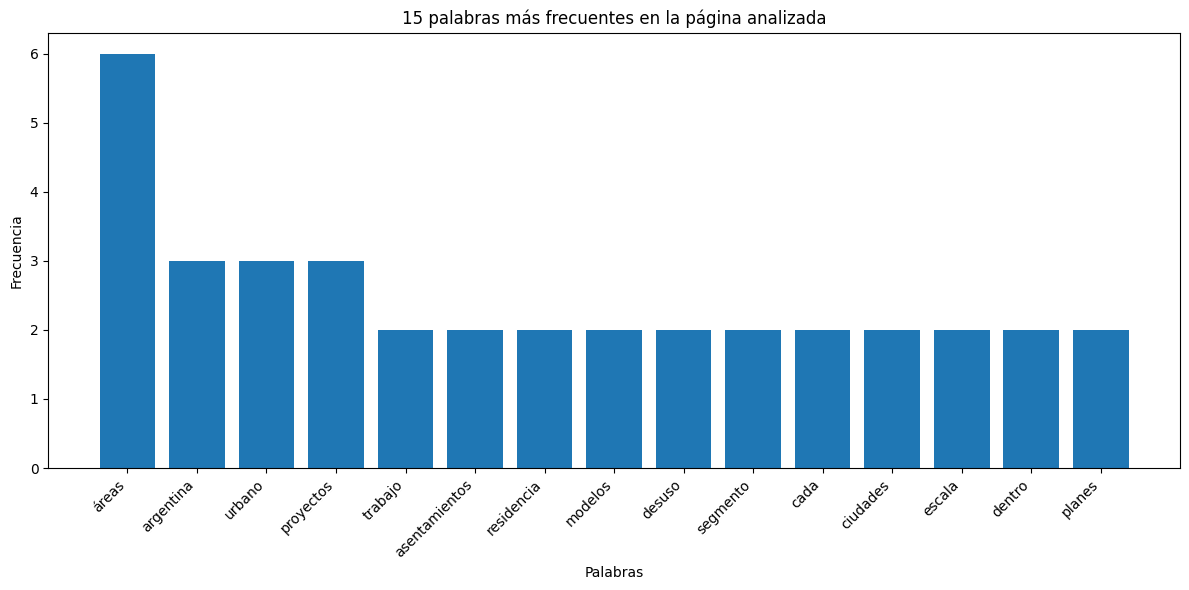

In [ ]:
import matplotlib.pyplot as plt

palabras = [palabra for palabra, frecuencia in top_15]
valores = [frecuencia for palabra, frecuencia in top_15]

plt.figure(figsize=(12, 6))
plt.bar(palabras, valores)
plt.xticks(rotation=45, ha='right')
plt.title("15 palabras más frecuentes en la página analizada")
plt.xlabel("Palabras")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

Con esos tokens limpios calculé la frecuencia de aparición y armé un gráfico con las 15 palabras más frecuentes. En los resultados se destacan términos como "áreas", "urbano", "proyectos", "planes" y "ciudades", lo que refleja claramente que el texto está enfocado en el desarrollo urbano y la planificación territorial.

En particular, la palabra "áreas" aparece con mayor frecuencia, lo que tiene sentido porque el texto habla constantemente de organización del espacio, uso del suelo y distintas zonas dentro de las ciudades.

###¿ Te surgieron en esta visualización tokens que también considerarías stop words? Comenta y justifica.

Si, durante el análisis surgieron tokens que, si bien no forman parte de las stop words tradicionales, podrían considerarse poco relevantes para este contexto específico.

Por ejemplo, palabras como "argentina" o "cada" aparecen con frecuencia, pero no aportan información significativa sobre el contenido temático del texto. Este tipo de palabras podrían considerarse como "stop words de contexto", ya que su importancia depende del análisis.

Esto evidencia que, en análisis más avanzados, no alcanza con utilizar listas estándar de stop words, sino que puede ser necesario construir listas personalizadas según el contexto del problema.

## Conclusión

El trabajo permitió observar las dificultades reales del procesamiento de datos no estructurados, especialmente en archivos PDF. Se evidenció que tanto la extracción de texto como de tablas puede presentar inconsistencias que requieren procesos de limpieza y transformación adicionales.

Asimismo, el análisis de frecuencias permitió identificar los principales conceptos del documento, aunque también puso en evidencia la necesidad de un preprocesamiento más avanzado para evitar la aparición de tokens irrelevantes o incompletos.

En conjunto, este trabajo demuestra la importancia del preprocesamiento en tareas de NLP y análisis de datos.

## Referencias y herramientas utilizadas
- Documentación oficial de PyMuPDF (fitz): https://pymupdf.readthedocs.io/
- Documentación oficial de pdfplumber: https://github.com/jsvine/pdfplumber
- Documentación de NLTK: https://www.nltk.org/
- Stopwords en español (NLTK): https://www.nltk.org/nltk_data/
- Material de clase – Unidad 1 Procesamiento del Lenguaje Natural
- ChatGPT (OpenAI) utilizado como asistencia para comprensión conceptual y resolución de problemas

Se utilizaron recursos complementarios de aprendizaje (Keith Galli) para reforzar conceptos de manipulación de datos con NumPy y Pandas.
- Keith Galli – NumPy Tutorial (YouTube): https://www.youtube.com/watch?v=QUT1VHiLmmI
- Keith Galli – Pandas Data Science Tutorial (YouTube): https://www.youtube.com/watch?v=vmEHCJofslg
